<a href="https://colab.research.google.com/github/ps4917/Midterm-Project/blob/main/Midterm_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Development Trends: Analytical Regions

##Executive Summary
This analysis explores development trends across the World Bank’s defined analytical regions, using data from 2000 to 2021. It examines how the economic regions have evolved over time, in terms of GDP per capita and GDP growth, and how these changes have influenced regional poverty levels and human capital. On the human capital side, several standard indicators reflecting broader health and education outcomes are studied, as they are among the most important factors affecting economic growth. Additionally, this work investigates differences across regions based on prominent economic industries and labor involvement, linking these factors to overall economic development.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install wbgapi # Using the World Bank API to access the needed dataset
import wbgapi as wb

In [ ]:
wb.series.info(q="GDP")
wb.series.info(q="poverty")
wb.series.info(q="income")
wb.series.info(q="share")# Checking on different indicators to extract the index of list of variables

id,value
CM.MKT.TRNR,"Stocks traded, turnover ratio of domestic shares (%)"
SE.LPV.PRIM,Learning poverty: Share of Children at the End-of-Primary age below minimum reading proficiency adjusted by Out-of-School Children (%)
SE.LPV.PRIM.FE,Learning poverty: Share of Female Children at the End-of-Primary age below minimum reading proficiency adjusted by Out-of-School Children (%)
SE.LPV.PRIM.MA,Learning poverty: Share of Male Children at the End-of-Primary age below minimum reading proficiency adjusted by Out-of-School Children (%)
SH.DYN.AIDS.FE.ZS,Women's share of population ages 15+ living with HIV (%)
SI.DST.02ND.20,Income share held by second 20%
SI.DST.03RD.20,Income share held by third 20%
SI.DST.04TH.20,Income share held by fourth 20%
SI.DST.05TH.20,Income share held by highest 20%
SI.DST.10TH.10,Income share held by highest 10%


#####The following list of variables are chosen to study the development patterns in the World Bank analytical region and its relationship with poverty, health, and employment. The variables are chosen to best reflect the broader situation of the economies while being within the scope of the work.

**Economy**\
NY.GDP.PCAP.PP.CD	GDP per capita, PPP (current international $)\
NY.GDP.MKTP.KD.ZG	GDP growth (annual %)


**Employment**\
SL.UEM.TOTL.ZS	Unemployment, total (% of total labor force) (modeled ILO estimate)\
SL.IND.EMPL.ZS	Employment in industry (% of total employment) (modeled ILO estimate)\
SL.AGR.EMPL.ZS	Employment in agriculture (% of total employment) (modeled ILO estimate)\
SL.SRV.EMPL.ZS	Employment in service (% of total employment) (modeled ILO estimate)\


**Poverty**\
SI.POV.DDAY	Poverty headcount ratio at 3.00 dollars a day (2021 PPP) (% of population)\
SI.DST.05TH.20	Income share held by highest 20%\
SI.DST.FRST.20	Income share held by lowest 20%

**Health**\
SP.DYN.LE00.IN	Life expectancy at birth, total (years)\
SH.DYN.MORT	Mortality rate, under-5 (per 1,000 live births)\

**Education**\
SE.SEC.ENRR	School enrollment, secondary (% gross)\
SE.SEC.ENRR.FE	School enrollment, secondary, female (% gross)\
SE.SEC.ENRR.MA	School enrollment, secondary, male (% gross)

In [ ]:
# Descriptions of each variable
descriptions = {
    'gdp_per_capita': 'GDP per capita, PPP (current international $)',
    'gdp_growth': 'GDP growth (annual %)',
    'poverty_rate': 'Poverty headcount ratio at $3.00/day (2021 PPP) (% of population)',
    'life_expectancy': 'Life expectancy at birth, total (years)',
    'child_mortality': 'Mortality rate, under-5 (per 1,000 live births)',
    'secondary_enrollment_net': 'School enrollment, secondary (% net)',
    'secondary_enrollment_female': 'School enrollment, secondary, female (% net)',
    'secondary_enrollment_male': 'School enrollment, secondary, male (% net)',
    'unemployment_rate': 'Unemployment, total (% of total labor force)',
    'industry_employment_pct': 'Employment in industry (% of total employment)',
    'agriculture_employment_pct': 'Employment in agriculture (% of total employment)',
    'service_employment_pct': 'Employment in service (% of total employment)',
    'income_highest20': 'Income share held by highest 20%',
    'income_lowest20': 'Income share held by lowest 20%'
}

In [ ]:
# Each of the World Bank code is assigned to the respective variables for dataframe creation

indicators={'NY.GDP.PCAP.PP.CD': 'gdp_per_capita',
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
    'SI.POV.DDAY': 'poverty_rate',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SH.DYN.MORT': 'child_mortality',
    'SE.SEC.NENR': 'secondary_enrollment_net',
    'SE.SEC.NENR.FE': 'secondary_enrollment_female',
    'SE.SEC.NENR.MA': 'secondary_enrollment_male',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SL.IND.EMPL.ZS': 'industry_employment_pct',
    'SL.AGR.EMPL.ZS': 'agriculture_employment_pct',
    'SL.SRV.EMPL.ZS': 'service_employment_pct',
    'SI.DST.05TH.20':	'Income share held by highest 20%',
    'SI.DST.FRST.20':	'Income share held by lowest 20%'
}

In [ ]:
regions = ['WLD','NAC', 'EAS', 'ECS', 'LCN', 'MEA', 'SAS', 'SSF'] # Using the World Bank analytical region to reduce the dimensionality of the dataset for broader EDA;\ this allows to look at the world trend rather than sticking up to a single economy
year=range(2000,2022) # Setting up the years of study

# Creating the dataframe
dev_df = wb.data.DataFrame(
    indicators.keys(),
    economy=regions,
    time=year,
    labels=True,
    columns='series'
)

# Rename indicator columns
dev_df.rename(columns=indicators, inplace=True)


In [ ]:
dev_df.head(100) #Visualizing the dataset

Country  Time  gdp_growth  gdp_per_capita  \
economy time                                                              
SSF     YR2021     Sub-Saharan Africa  2021    4.314826     4247.462171   
        YR2020     Sub-Saharan Africa  2020   -1.994294     3976.606916   
        YR2019     Sub-Saharan Africa  2019    2.696697     4048.571925   
        YR2018     Sub-Saharan Africa  2018    2.774839     3888.604475   
        YR2017     Sub-Saharan Africa  2017    2.512523     3864.903880   
...                               ...   ...         ...             ...   
ECS     YR2014  Europe & Central Asia  2014    1.943634    30596.811618   
        YR2013  Europe & Central Asia  2013    0.871565    29835.988990   
        YR2012  Europe & Central Asia  2012    0.311078    28527.667185   
        YR2011  Europe & Central Asia  2011    2.376612    27777.380239   
        YR2010  Europe & Central Asia  2010    2.625562    26191.442540   

                secondary_enrollment_net  secondary_enrollment_female  \
economy time                                                            
SSF     YR2021                       NaN                          NaN   
        YR2020                       NaN                          NaN   
        YR2019                       NaN                          NaN   
        YR2018                  35.58426                     33.98075   
        YR2017                  35.29055                     33.65090   
...                                  ...                          ...   
ECS     YR2014                  89.92729                     89.98592   
        YR2013                  89.42010                     89.41179   
        YR2012                  88.28786                     88.29068   
        YR2011                  88.24032                     88.17146   
        YR2010                  87.83752                     87.80594   

                secondary_enrollment_male  child_mortality  \
economy time                                                 
SSF     YR2021                        NaN             72.7   
        YR2020                        NaN             74.7   
        YR2019                        NaN             77.7   
        YR2018                   37.16512             79.8   
        YR2017                   36.90711             84.2   
...                                   ...              ...   
ECS     YR2014                   89.87258             10.0   
        YR2013                   89.42876             10.4   
        YR2012                   88.28576             10.8   
        YR2011                   88.30672             11.2   
        YR2010                   87.86743             11.7   

                Income share held by highest 20%  \
economy time                                       
SSF     YR2021                               NaN   
        YR2020                               NaN   
        YR2019                               NaN   
        YR2018                               NaN   
        YR2017                               NaN   
...                                          ...   
ECS     YR2014                               NaN   
        YR2013                               NaN   
        YR2012                               NaN   
        YR2011                               NaN   
        YR2010                               NaN   

                Income share held by lowest 20%  poverty_rate  \
economy time                                                    
SSF     YR2021                              NaN          46.6   
        YR2020                              NaN          46.4   
        YR2019                              NaN          44.4   
        YR2018                              NaN          44.6   
        YR2017                              NaN          45.0   
...                                         ...           ...   
ECS     YR2014                              NaN           1.2   
        YR2013                     

In [ ]:
dev_df.shape # The size of dataset
dev_df.isna().sum() # Checking if there are any missing values and summing them up

,0
Country,0
Time,0
gdp_growth,0
gdp_per_capita,0
secondary_enrollment_net,24
secondary_enrollment_female,24
secondary_enrollment_male,24
child_mortality,0
Income share held by highest 20%,176
Income share held by lowest 20%,176


Since 6 of the variables have some missing values, we need to fix this first before procceding with further analysis. This is a panel dataset, hence, the imputation might not be as good as imputing cross-sectional data. The data showed some time trend from the initial overlook using df.head() command, thus I'm imputing the missing values using the median for each region. However, 2 of the variables misses all the values, so these variables won't be used for further analysis.

In [ ]:
dev_df['poverty_rate'].median()
dev_df['secondary_enrollment_net'].median()
dev_df['secondary_enrollment_female'].median()
dev_df['secondary_enrollment_male'].median()

68.02828

In [ ]:
# Fill missing values of each variable with the median of its region

dev_df['poverty_rate'] = dev_df['poverty_rate'].fillna(
    dev_df.groupby('economy')['poverty_rate'].transform('median')
)

dev_df['secondary_enrollment_net'] = dev_df['secondary_enrollment_net'].fillna(
    dev_df.groupby('economy')['secondary_enrollment_net'].transform('median')
)

dev_df['secondary_enrollment_female'] = dev_df['secondary_enrollment_female'].fillna(
    dev_df.groupby('economy')['secondary_enrollment_female'].transform('median')
)

dev_df['secondary_enrollment_male'] = dev_df['secondary_enrollment_male'].fillna(
    dev_df.groupby('economy')['secondary_enrollment_male'].transform('median')
)

In [ ]:
# Verifying the imputation of poverty rate and education expenditure variables.
dev_df.isna().sum()

,0
Country,0
Time,0
gdp_growth,0
gdp_per_capita,0
secondary_enrollment_net,0
secondary_enrollment_female,0
secondary_enrollment_male,0
child_mortality,0
Income share held by highest 20%,176
Income share held by lowest 20%,176


###Question 1
Can you see any pattern between GDP Growth and GDP per capita?

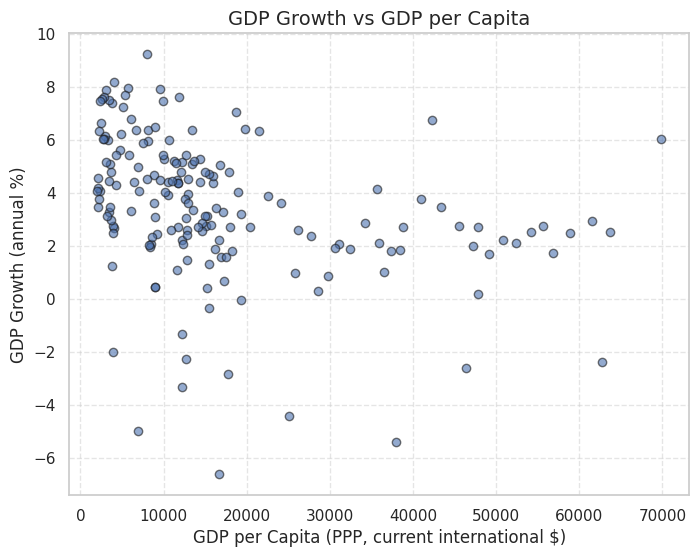

In [ ]:
# Scatter plot of GDP per capita vs GDP growth

plt.figure(figsize=(8, 6)) # Customizing the size of plot
plt.scatter(dev_df['gdp_per_capita'], dev_df['gdp_growth'], alpha=0.6, edgecolor='k') # Plotting GDP per capita on x-axis and GDP Growth on Y-axis

plt.title('GDP Growth vs GDP per Capita', fontsize=14) # Naming the Plot Title
plt.xlabel('GDP per Capita (PPP, current international $)', fontsize=12) # Naming the axis
plt.ylabel('GDP Growth (annual %)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5) # Shows the grid on the background, easy for visualising each point (if needed)

plt.show()


In line with the theory of convergence, countries with lower GDP per capita tend to have higher economic growth rate. This is because poorer countries have lower capital and each additional unit of capital tend to have higher marginal return than richer countries. However, this theroy is pretty vague and not necessarily true considering other factors influencing growth like technology, instituitons and so on. Having said that, the above scatterplot show some kind of evidence that poorer countries have higher GDP growth rate (clustering on the top left).

###Question 2
What about poverty and GDP per capita? Also, poverty and Economic Growth? Which of GDP per capita or GDP growth better reflect the poverty in an economy?

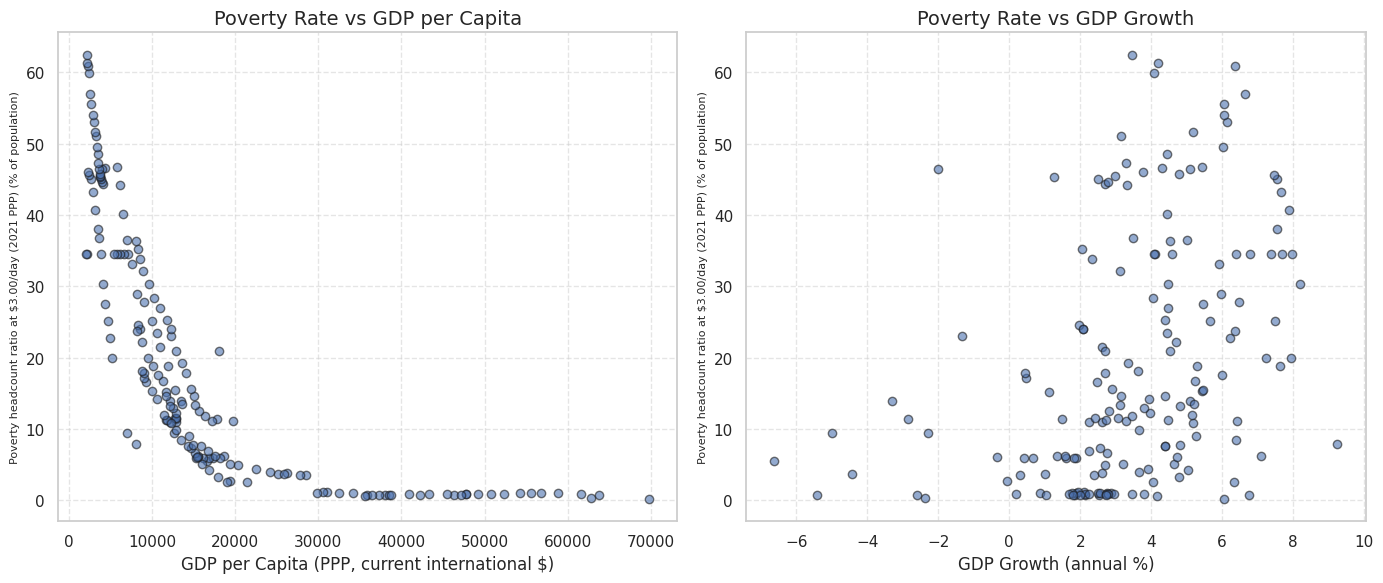

In [ ]:
plt.figure(figsize=(14, 6))

# Scatter plot of GDP per capita vs Poverty rate
plt.subplot(1, 2, 1)

plt.scatter(dev_df['gdp_per_capita'], dev_df['poverty_rate'], alpha=0.6, edgecolor='k')
plt.title('Poverty Rate vs GDP per Capita', fontsize=14)
plt.xlabel('GDP per Capita (PPP, current international $)', fontsize=12)
plt.ylabel('Poverty headcount ratio at $3.00/day (2021 PPP) (% of population)', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)


# Scatter plot of GDP growth rate vs Poverty rate
plt.subplot(1, 2, 2)

plt.scatter(dev_df['gdp_growth'], dev_df['poverty_rate'], alpha=0.6, edgecolor='k')

plt.title('Poverty Rate vs GDP Growth', fontsize=14)
plt.xlabel('GDP Growth (annual %)', fontsize=12)
plt.ylabel('Poverty headcount ratio at $3.00/day (2021 PPP) (% of population)', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Clearly, GDP per capita reflect better information on poverty rate. Economy with higher GDP per capita tends to have lower (almost 0) poverty rate and vice versa. However, no clear trend can be deduced from the graph of Poverty rate against GDP growth rate.

###Question 3
Now, from broader theoretical perspective, lets dive deeper into the regional GDP per capita and GDP growth rate. How do they differ by region?

/tmp/ipython-input-1107961081.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-1107961081.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


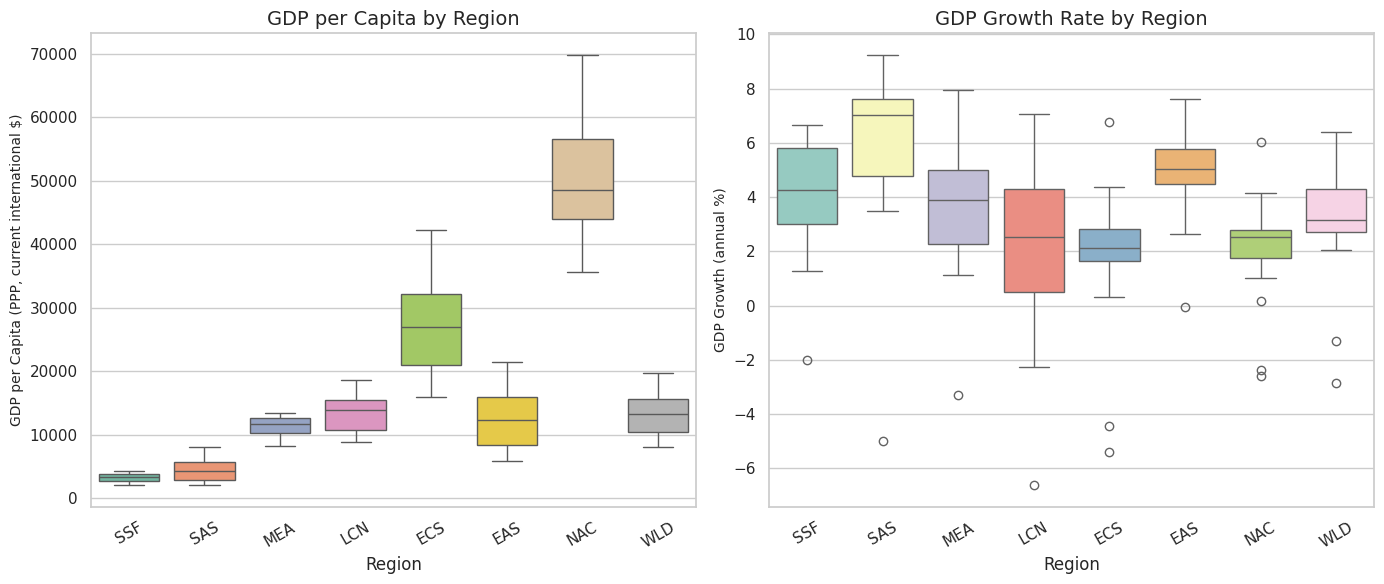

In [ ]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: GDP per capita distribution by region
sns.boxplot(
    data=dev_df,
    x='economy',
    y='gdp_per_capita',
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('GDP per Capita by Region', fontsize=14)
axes[0].set_xlabel('Region', fontsize=12)
axes[0].set_ylabel('GDP per Capita (PPP, current international $)', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)

#  GDP growth distribution by region
sns.boxplot(
    data=dev_df,
    x='economy',
    y='gdp_growth',
    ax=axes[1],
    palette='Set3'
)
axes[1].set_title('GDP Growth Rate by Region', fontsize=14)
axes[1].set_xlabel('Region', fontsize=12)
axes[1].set_ylabel('GDP Growth (annual %)', fontsize=10)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


The boxplot above shows the stark difference in the GDP per capita between regions over the time. Sub-Sharan Africa (SSF) has the lowest GDP per capita and North America (NAC) has the highest.

On the other hand, GDP Growth Rate is quite comparable across region in contrast to GDP per capita. The economic growth rate of region with lower GDP per capita tend to hover at higher values compared to the region with higher GDP per capita. Interestingly, economic regions with higher GDP per capita seem to expereince more recessions compared to the regions with lower GDP per capita. For example, 2 negative growth periods in North America (NAC), Europe & Central Asia (ECS) to 1 in Sub-Sahran Africa (SSF), South Asia (SAS) and Middle East and North Africa (MEA).



### Question 4
Since GDP growth rate is negative over all region at some point of time, we will analyse the GDP growth trend over years for each region. Is there a particular reason behind it?

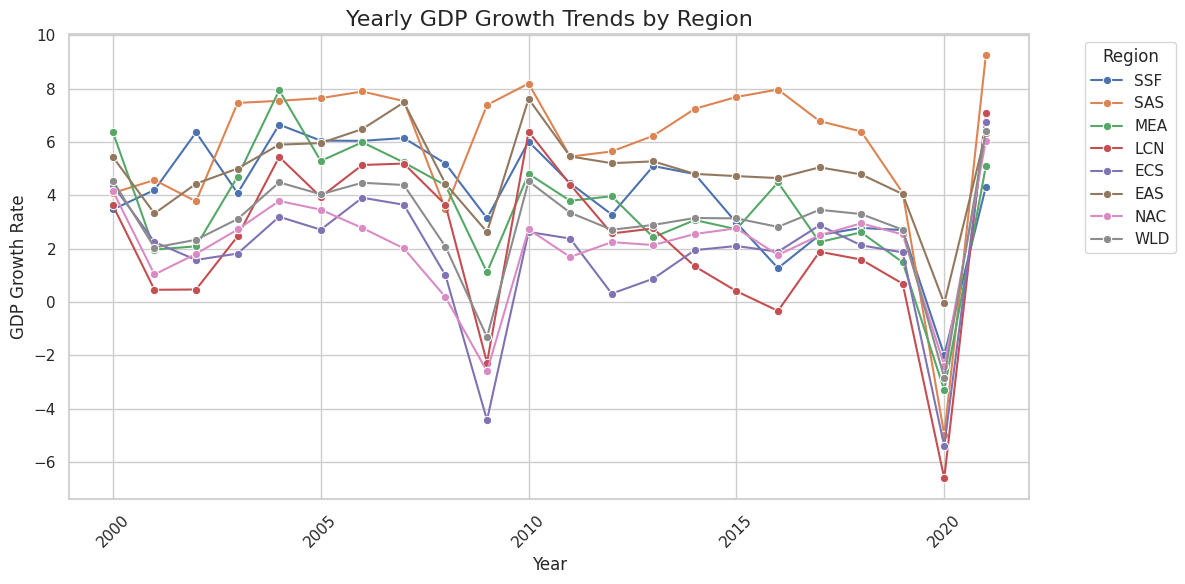

In [ ]:
# Changing 'time' to numeric; this organizes time in ascending order for visualizing yearly trends
dev_df['Time'] = pd.to_numeric(dev_df['Time'], errors='coerce')

sns.set(style="whitegrid")

# Line plot: GDP Growth Trends for all regions

plt.figure(figsize=(12, 6))
sns.lineplot(data=dev_df, x='Time', y='gdp_growth', hue='economy', marker='o')

plt.title('Yearly GDP Growth Trends by Region', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP Growth Rate', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The above graph is quite complicated to interpret. The GDP growth rates of different region do not show a similar trend in overall, meaning that the economy responded only to the regional shocks (negative or positive) in most of the timeframe. However, during the period of global shocks like the Covid-19 or the Global Financial Crisis (GFC), every regional economy expreienced either poor or negative economic growth.

### Question 5
Although it is obvious that poverty is more or less described by GDP per capita, let us look at the poverty rate by region.

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=dev_df,
    x='economy',
    y='poverty_rate',  # variable to plot
    palette='Set2'
)

# Set titles and labels using plt
plt.title('Poverty Rate by Region', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Poverty Rate (%)', fontsize=12)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()



As expected, Sub-Saharan Africa (SSF) has the highest poverty rate and North America (NAC) has the lowest (almost 0). The interesting of all is the East Asia and Pacific (EAS) whose poverty rate, at one point, was around 50%. Let us look deeper how has it changed with time.

In [ ]:
sns.set(style="whitegrid")

# Reset index to make 'economy' a column
dev_df_reset = dev_df.reset_index()

# Filter for EAS region
eas_df = dev_df_reset[dev_df_reset['economy'] == 'EAS']

# Plot poverty rate trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=eas_df, x='Time', y='poverty_rate', marker='o')

plt.title('Poverty Rate Trends in EAS Region', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Poverty Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
dev_df.groupby('economy')['gdp_growth'].mean() # Done to see the GDP growth rate across region

In [ ]:
# Extracting gdppc of each region for the year 2000
gdppc_2000 = dev_df[dev_df['Time'] == 2000].groupby('economy')['gdp_per_capita'].mean()

print(gdppc_2000)

The EAS region did a commendable job in reducing poverty from around 50% to below 5% in a span of 20 years. This is because of the fact that EAS region consistently averaged a higher economic growth rate of 4.95% and started up higher. However, SAS cannot reduce the poverty at the same rate as EAS despite having a growth rate close to 6%. This is because of the fact that SAS region started at a much lower GDP per capita ($2050) compared to EAS (5800) , and as we have already seen above, GDP pc better associates with the poverty data than GDP growth.

### Question 6
After we looked at the relationship between GDP per capita and poverty, let's study the implication of poverty in the human capital (specifically health and education), as these factors are key to achieve economic growth. Is poverty rate associated with health and education outcomes?

In [ ]:
dev_df.groupby('economy')[['life_expectancy','child_mortality']].mean() # Grouping the mean value of life expectancy and child mortality over regions to see the long term regional trend

Sub-Saharan Africa (SSF), South Asia (SAS) and Middle East North Africa (MEA) have life expectancy below the World Average across the period of time. MEA does better on child mortality but the SAS and SSF remain above the world average.

In [ ]:

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Left plot: Child Mortality trends
sns.lineplot(
    data=dev_df,
    x='Time',
    y='child_mortality',
    hue='economy',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Child Mortality Trends by Region', fontsize=14)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Child Mortality Rate per 1000 live births', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

# Right plot: Life Expectancy trends
sns.lineplot(
    data=dev_df,
    x='Time',
    y='life_expectancy',
    hue='economy',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Life Expectancy Trends by Region', fontsize=14)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Life Expectancy (years)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


However, there is something to be hopeful of as the child mortality in all of the regions are decreasing, and specially at higher pace in SSF, SAS and MEA.

Life expectancy shows an increasing trend overall. But, the life expectancy declined sharply in all region during 2020 due to the Covid-19.

In [ ]:
dev_df[['poverty_rate', 'child_mortality','life_expectancy']].corr() # Checking out correlation to see the association between three variables


There is a very high positive correlation between poverty rate and child mortality, meaning that higher poverty rate is associated with higher child mortality. However, it might not be true to say that higher poverty rate leads to higher child mortality rate. Similarly, there is a high negative correlation between life expectancy and poverty rate i.e. higher poverty is associated with lower life expectancy.

Now, let's look at the similar sort of information in the educational sector. Instead of showing the trend as above, here I will try to grasp important information (long run regional differences and yearly trend) using summary statistics.

In [ ]:
dev_df.groupby('economy')['secondary_enrollment_net'].mean() # Grouping the mean value of life expectancy and child mortality over regions to see the long term regional trend

Sub-Saharan Africa (SSF) has the least secondary average school enrollment and Europe & Central Asia (ECS) has the highest average enrollment over the period of 2000-2020. This output is showing the long run difference across different region.

In [ ]:
dev_df.groupby('time')['secondary_enrollment_net'].mean() # This shows the yearly trend of the secondary education enrollment across
# This is simply another way of putting the trens in numbers instead of graph. Sometimes, these sorrt of data would be useful for further analysis going beyond EDA.

However, this this output is showing the yearly trend reflecting all the region. This is helpful in seeing the overall trend, while the above is helpful in analysing regional differences. The last three values equal 66.39 because I imputed the missing value with the median earlier.

Now, let's look at how the education enrollment differ by gender across different region. This would give us a general idea on gender parity.

In [ ]:
dev_df.groupby('economy')[['secondary_enrollment_female', 'secondary_enrollment_male']].mean()

In [ ]:
dev_df.groupby('time')[['secondary_enrollment_female', 'secondary_enrollment_male']].mean()

Both the male and female enrollment are increasing over the years. However, female enrollment is lower in the least developed region (SSF, SAS and MEA) compared to male enrollment. In contrast, female enrollment is higher in region like North Ameirca and Europe highlighting gender parity in educational enrollment.

### Question 7
Visually and through EDA, we see convincing evidence of poorer regions like SAF and SAS falling behind in terms of health and education. Now, we will see the relationship between poverty rate, employment and economic growth.

In [ ]:
dev_df[['poverty_rate', 'unemployment_rate']].corr() # Follows up the tools used above

In [ ]:
dev_df.groupby('economy')['unemployment_rate'].mean()

Surprisingly, unemployment rate and poverty rate seem to have a weak negative correlation. Likewise, there is not a stark difference in the unemployment rate across different regions. Except for the East Asia and Pacific (EAS), the average employment rate is above 6% for all else. SSF (region with the highest poverty rate) has equal unemployment rate to NAC (region with the lowest poverty rate).

In [ ]:
plt.figure(figsize=(14, 6))

# Scatter plot of Share of service employment vs Poverty rate
plt.subplot(1, 2, 1)

plt.scatter( dev_df['poverty_rate'],dev_df['service_employment_pct'], alpha=0.6, edgecolor='k')
plt.title('Poverty Rate vs Share of Service Employment', fontsize=14)
plt.xlabel('Poverty headcount ratio at $3.00/day (2021 PPP) (% of population)', fontsize=10)
plt.ylabel('Share of Service Employment', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)


# Scatter plot of GDP growth rate vs Share of service employment
plt.subplot(1, 2, 2)

plt.scatter(dev_df['gdp_growth'],dev_df['service_employment_pct'], alpha=0.6, edgecolor='k')

plt.title('Share of Service Employment vs GDP Growth', fontsize=14)
plt.xlabel('GDP Growth (annual %)', fontsize=12)
plt.ylabel('Share of Service Employment', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The graphs above are very interesting. I created those graphs under my assumption that bigger share of employment in service sector is associated with higher economic growth which is visibly not true. The points are scattered all over.

However, the most interesting part of the left graph above is the clustering of points into multiple groups. Each groups representing a pattern is a specific region. Each point on the graph is a plot for a specific region at a specific year. And, if we look closely at each of the pattern, it is downward sloping. Combined with our findings from previous analysis that poverty rate is decreasing over the years in all region, we can say that over the years service industry is expanding for most of the region and simultaneously the poverty rate is decreasing.

In [ ]:
plt.figure(figsize=(14, 6))

# Scatter plot of Share of service employment vs Poverty rate
plt.subplot(1, 2, 1)

plt.scatter( dev_df['poverty_rate'],dev_df['agriculture_employment_pct'], alpha=0.6, edgecolor='k')
plt.title('Poverty Rate vs Share of Agriculture Employment', fontsize=14)
plt.xlabel('Poverty headcount ratio at $3.00/day (2021 PPP) (% of population)', fontsize=10)
plt.ylabel('Share of Agriculture Employment', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)


# Scatter plot of GDP growth rate vs Share of service employment
plt.subplot(1, 2, 2)

plt.scatter(dev_df['gdp_growth'],dev_df['agriculture_employment_pct'], alpha=0.6, edgecolor='k')

plt.title('Share of Agriculture Employment vs GDP Growth', fontsize=14)
plt.xlabel('GDP Growth (annual %)', fontsize=12)
plt.ylabel('Share of Agriculture Employment', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Similar to above analysis, no clear pattern can be seen in the right graph.

However, the clustering of the points in the left graph tells a similar story. The clustering of the points also reflect about the stickiness of the both the x and y variables i.e. both of them cannot increase or decrease by a large in a period of year or even a decade. The pattern is upward sloping; higher poverty ratio means higher share in agriculture. The poverty ratio is decreasing over the years in all region, so this implies that the share of agriculture employment is decreasing in most of the regional economies.

In [ ]:
plt.figure(figsize=(14, 6))

# Scatter plot of Share of service employment vs Poverty rate
plt.subplot(1, 2, 1)

plt.scatter( dev_df['poverty_rate'],dev_df['industry_employment_pct'], alpha=0.6, edgecolor='k')
plt.title('Poverty Rate vs Share of Industrial Employment', fontsize=14)
plt.xlabel('Poverty headcount ratio at $3.00/day (2021 PPP) (% of population)', fontsize=10)
plt.ylabel('Share of Industrial Employment', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)


# Scatter plot of GDP growth rate vs Share of service employment
plt.subplot(1, 2, 2)

plt.scatter(dev_df['gdp_growth'],dev_df['industry_employment_pct'], alpha=0.6, edgecolor='k')

plt.title('Share of Industrial Employment vs GDP Growth', fontsize=14)
plt.xlabel('GDP Growth (annual %)', fontsize=12)
plt.ylabel('Share of Industrial Employment', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Less clear and distinct pattern in the Share of Instrial employment vs Poverty rate graph as compared to the above two. But broadly speaking, regional economies with higher share of employment in industrial sector tend to have lower poverty rate.


To summarise the overall description, the above data shows an increasing share of employment in service and industrial sector and decreasing share of agriculture employment leading to a decline in poverty rate.

In [ ]:
dev_df.groupby('time')[['industry_employment_pct', 'service_employment_pct', 'agriculture_employment_pct']].mean()

The table above more or less numerically verifies the trend analysis.

To summarise, although the scope of the work limited to Exploratory Data Analysis doesn't allow us to see causal impact and make strong statistical statement about the interaction between different socio-economic variables, this analysis build up a strong foundation to visualise the trend and learn the differences among regions and over time. Broadly speaking, we see that economies with higher GDP per capita tend to have better education and health as expected. Economic growth, as seen in the data, is relatively higher for the poor economies (the range from the boxplot), but no clear determinstic trend was seen. In the labor force, industry and service industry seem to be growing with agriculture sector shrinking over the years.